In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [13]:
# 1. Baca sumber datanya
df = pd.read_csv('../../data/03_interim/answer_quality_dataset_dirty.csv')

print(f"Total Data: {df.shape[0]} Baris")
df.head()

Total Data: 5239 Baris


,sample_id,domain,role_family,target_role,competency,question,answer,role_relevance,star_structure,evidence_specificity,...,clarification_type,final_score_0_100,final_score_0_1,quality_label,has_tool,has_metric,has_impact,has_action,has_context,answer_length_words
0,AQD-03716F,Information & Technology,Data & AI,ML Engineer,Automated MLOps Pipelines,Pernahkah kamu terlibat dalam merancang pipeli...,"Iya, saya pernah terlibat dalam perancangan pi...",70.0,65.0,50.0,...,metric,62.25,0.6225,Average,1,0,0,1,1,130
1,AQD-FA7056,Information & Technology,Data & AI,ML Engineer,Career Motivation & Fit,"Kalau kamu diterima di posisi ML Engineer ini,...",Target utama saya dalam satu sampai dua tahun ...,95.0,90.0,95.0,...,none,92.55,0.9255,Strong,1,1,1,1,1,119
2,AQD-433BB3,Information & Technology,Data & AI,AI Engineer,Career Motivation & Fit,Dari semua project atau materi yang pernah kam...,Saya rasa titik balik yang paling signifikan b...,70.0,60.0,74.0,...,impact,67.30,0.6730,Average,1,0,0,1,1,152
3,AQD-B7FDA1,Information & Technology,Data & AI,AI Engineer,Deep Learning Architecture Design,Saat proses pelatihan (training) model deep le...,"Eh, anu... kalau soal itu ya, emm, sebenernya ...",40.0,20.0,20.0,...,context,28.00,0.2800,Weak,0,0,0,0,0,105
4,AQD-95CDCC,Information & Technology,Software Tester,QA Automation Engineer,Programmatic Integration Validation,Misalkan skrip otomatisasi API kamu berjalan s...,"Em, jadi kalau buat kasus itu, biasanya saya p...",70.0,60.0,50.0,...,technical,61.25,0.6125,Average,1,0,0,1,1,113


In [15]:
# 1. Mengecek Informasi Umum Dataset
print("=== INFO DATASET ===")
df.info()

# Mengecek total Missing Values per kolom
print("\n=== MISSING VALUES ===")
print(df.isna().sum())

# 2. Mengecek Data Duplikat
print("=== DATA DUPLIKAT ===")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

# 3. Mengecek Inkonsistensi Format (Kondisi Label)
print("=== KONDISI LABEL KUALITAS ===")
print(df['quality_label'].value_counts(dropna=False))

# 4. Mengecek Anomali Numerik (Statistik Deskriptif)
print("=== STATISTIK NUMERIK ===")
print(df['answer_length_words'].describe())

=== INFO DATASET ===


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5239 entries, 0 to 5238
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sample_id              5239 non-null   object 
 1   domain                 5239 non-null   object 
 2   role_family            5239 non-null   object 
 3   target_role            5239 non-null   object 
 4   competency             5239 non-null   object 
 5   question               5239 non-null   object 
 6   answer                 5228 non-null   object 
 7   role_relevance         5237 non-null   float64
 8   star_structure         5226 non-null   float64
 9   evidence_specificity   5237 non-null   float64
 10  technical_accuracy     5237 non-null   float64
 11  communication_clarity  5236 non-null   float64
 12  self_awareness         5237 non-null   float64
 13  evidence_level         5239 non-null   int64  
 14  weakness_tags          3492 non-null   object 
 15  need

In [3]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 12))

<Figure size 1800x1200 with 0 Axes>

<Figure size 1800x1200 with 0 Axes>

C:\Users\nurul\AppData\Local\Temp\ipykernel_1008\1022257376.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='quality_label', palette={'Weak': '#ff9999', 'Average': '#ffcc99', 'Strong': '#99cc99'}, order=['Weak', 'Average', 'Strong'])


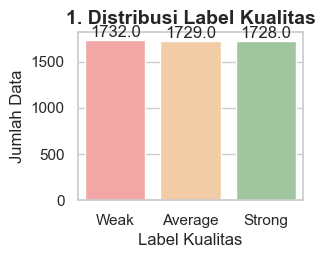

In [4]:
# ==========================================
# PLOT 1: Distribusi Kualitas (Balance Check)
# ==========================================
plt.subplot(2, 2, 1)
ax = sns.countplot(data=df, x='quality_label', palette={'Weak': '#ff9999', 'Average': '#ffcc99', 'Strong': '#99cc99'}, order=['Weak', 'Average', 'Strong'])
plt.title("1. Distribusi Label Kualitas", fontsize=14, fontweight='bold')
plt.xlabel("Label Kualitas")
plt.ylabel("Jumlah Data")
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=12)

C:\Users\nurul\AppData\Local\Temp\ipykernel_1008\612901821.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Text(0, 0.5, 'Jumlah Kata')

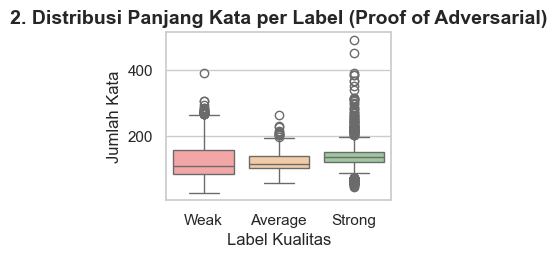

In [5]:
# ==========================================
# PLOT 2: Panjang Kata vs Kualitas 
# ==========================================
plt.subplot(2, 2, 2)

# 1. Pastikan kolom X adalah string
df['quality_label'] = df['quality_label'].astype(str)

# 2. Ambil data yang HANYA berisi 'Weak', 'Average', atau 'Strong' 
# (Ini buat ngebuang data 'nan' atau angka indeks tersembunyi yang bikin error)
df_plot = df[df['quality_label'].isin(['Weak', 'Average', 'Strong'])]

# 3. Pastikan kolom Y adalah numerik (float/int), jika ada teks nyasar diubah jadi NaN lalu dibuang
df_plot = df_plot.copy()
df_plot['answer_length_words'] = pd.to_numeric(df_plot['answer_length_words'], errors='coerce')
df_plot = df_plot.dropna(subset=['answer_length_words'])

# 4. Gambar grafiknya menggunakan data bersih (df_plot)
sns.boxplot(
    data=df_plot, 
    x='quality_label', 
    y='answer_length_words', 
    palette={'Weak': '#ff9999', 'Average': '#ffcc99', 'Strong': '#99cc99'}, 
    order=['Weak', 'Average', 'Strong']
)

plt.title("2. Distribusi Panjang Kata per Label (Proof of Adversarial)", fontsize=14, fontweight='bold')
plt.xlabel("Label Kualitas")
plt.ylabel("Jumlah Kata")

Text(0, 0.5, 'Kepadatan')

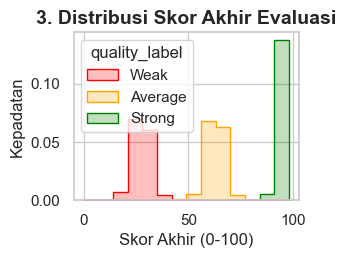

In [6]:
# ==========================================
# PLOT 3: Distribusi Skor Final (Melihat Sebaran 0-100)
# ==========================================
plt.subplot(2, 2, 3)
df['final_score_0_100'] = pd.to_numeric(df['final_score_0_100'], errors='coerce')
sns.histplot(
    data=df,
    x='final_score_0_100',
    hue='quality_label',
    hue_order=['Weak', 'Average', 'Strong'],
    palette=['red', 'orange', 'green'],
    element="step",
    stat="density",
    common_norm=False,
    multiple='layer'
)
plt.title("3. Distribusi Skor Akhir Evaluasi", fontsize=14, fontweight='bold')
plt.xlabel("Skor Akhir (0-100)")
plt.ylabel("Kepadatan")

C:\Users\nurul\AppData\Local\Temp\ipykernel_1008\1083340260.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=metric_stats.index, y=metric_stats.values, palette={'Weak': '#ff9999', 'Average': '#ffcc99', 'Strong': '#99cc99'})


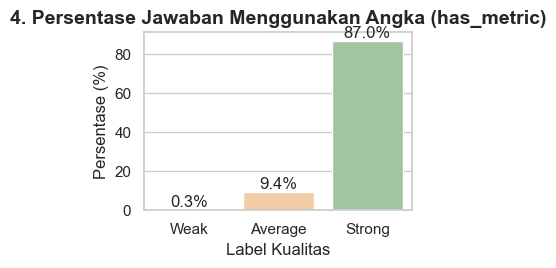

In [7]:
# ==========================================
# PLOT 4: Persentase "Has Metric" Berdasarkan Kualitas
# ==========================================
# Membuktikan bahwa Strong ada yang "No-Number" (has_metric=0) 
# dan Average/Weak ada yang "Misguided Metric" (has_metric=1)
plt.subplot(2, 2, 4)
metric_stats = df.assign(has_metric=pd.to_numeric(df['has_metric'], errors='coerce').fillna(0)).groupby('quality_label')['has_metric'].mean() * 100
metric_stats = metric_stats.reindex(['Weak', 'Average', 'Strong'])
ax2 = sns.barplot(x=metric_stats.index, y=metric_stats.values, palette={'Weak': '#ff9999', 'Average': '#ffcc99', 'Strong': '#99cc99'})
plt.title("4. Persentase Jawaban Menggunakan Angka (has_metric)", fontsize=14, fontweight='bold')
plt.xlabel("Label Kualitas")
plt.ylabel("Persentase (%)")
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

# SPLIT DATA

In [8]:
# --- TAMBAHAN KODE CLEANING ---
# Buang baris "penyusup" (baris yang isinya nama header/kolom)
df = df[df['quality_label'] != 'quality_label']
print(f"Data bersih siap di-split: {len(df)} baris\n")
# ------------------------------

Data bersih siap di-split: 5189 baris



In [9]:
# PEMBAGIAN PERTAMA: Ambil 70% untuk Train, 30% untuk Temp
# stratify=df['quality_label'] memastikan komposisi Weak/Average/Strong tetap adil
train_df, temp_df = train_test_split(
    df, 
    test_size=0.30, 
    random_state=42, # Biar kalau di-run ulang hasilnya gak berubah-ubah
    stratify=df['quality_label']
)

In [10]:
# PEMBAGIAN KEDUA: Bagi Temp (30%) menjadi dua sama rata (15% Val, 15% Test)
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.50, 
    random_state=42, 
    stratify=temp_df['quality_label']
)

In [ ]:
# CEK HASIL PEMBAGIAN (Sanity Check)
print("=== HASIL PEMBAGIAN DATA (70% : 15% : 15%) ===")
print(f"Total Data Train : {len(train_df)} baris ({len(train_df)/len(df)*100:.1f}%)")
print(f"Total Data Val   : {len(val_df)} baris ({len(val_df)/len(df)*100:.1f}%)")
print(f"Total Data Test  : {len(test_df)} baris ({len(test_df)/len(df)*100:.1f}%)\n")

print("=== DISTRIBUSI LABEL (Harus Seimbang!) ===")
print("Train Set:\n", train_df['quality_label'].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))
print("\nValidation Set:\n", val_df['quality_label'].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))
print("\nTest Set:\n", test_df['quality_label'].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))

# 5. SIMPAN KE 3 FILE CSV BERBEDA
train_df.to_csv('../../data/04_processed/dataset_train_v2.csv', index=False)
val_df.to_csv('../../data/04_processed/dataset_val_v2.csv', index=False)
test_df.to_csv('../../data/04_processed/dataset_test_v2.csv', index=False)

print("\n[+] Selesai!")

=== HASIL PEMBAGIAN DATA (70% : 15% : 15%) ===
Total Data Train : 3632 baris (70.0%)
Total Data Val   : 778 baris (15.0%)
Total Data Test  : 779 baris (15.0%)

=== DISTRIBUSI LABEL (Harus Seimbang!) ===
Train Set:
 quality_label
Weak       33.4%
Average    33.3%
Strong     33.3%
Name: proportion, dtype: object

Validation Set:
 quality_label
Weak       33.4%
Strong     33.3%
Average    33.3%
Name: proportion, dtype: object

Test Set:
 quality_label
Weak       33.4%
Average    33.4%
Strong     33.2%
Name: proportion, dtype: object


OSError: Cannot save file into a non-existent directory: '...\data_processed'